In [4]:
import pandas as pd

In [5]:
d_191013_11h = pd.read_csv("19WSC_csv/Australia_Racing_191013_11h.csv")
d_191013_14h = pd.read_csv("19WSC_csv/Australia_Racing_191013_14h.csv")
d_191013 = pd.concat([d_191013_11h, d_191013_14h], axis=0)
d_191013

,Time,Current1,Current2,Voltage,Speed,SOC,Distance,2
0,13/11:37:07,0.0,4.00,120.16,0.011,41.44,0.000,3
1,13/11:37:08,0.0,4.00,120.16,0.011,41.44,0.000,4
2,13/11:37:08,0.0,3.95,120.15,0.022,41.44,0.000,5
3,13/11:37:09,0.0,3.91,120.15,0.011,41.44,0.000,6
4,13/11:37:09,0.0,3.88,120.14,0.011,41.44,0.000,7
...,...,...,...,...,...,...,...,...
5149,13/15:28:46,0.0,1.14,108.76,0.022,25.18,250.866,5153
5150,13/15:28:46,0.0,1.14,108.76,0.033,25.18,250.866,5154
5151,13/15:28:47,0.0,1.14,108.76,0.022,25.18,250.866,5155
5152,13/15:28:48,0.0,1.14,108.75,0.022,25.18,250.866,5156


In [6]:
d_191013.isna().sum()

Time        0
Current1    0
Current2    0
Voltage     0
Speed       0
SOC         0
Distance    0
2           0
dtype: int64

In [7]:
full_time_strings = '2019-10-' + d_191013['Time']

d_191013['Time'] = pd.to_datetime(full_time_strings, format='%Y-%m-%d/%H:%M:%S')

In [8]:
d_191013.index = d_191013['Time']
d_191013.drop(["2", "Time"], inplace=True, axis=1)
d_191013

,Current1,Current2,Voltage,Speed,SOC,Distance
Time,,,,,,
2019-10-13 11:37:07,0.0,4.00,120.16,0.011,41.44,0.000
2019-10-13 11:37:08,0.0,4.00,120.16,0.011,41.44,0.000
2019-10-13 11:37:08,0.0,3.95,120.15,0.022,41.44,0.000
2019-10-13 11:37:09,0.0,3.91,120.15,0.011,41.44,0.000
2019-10-13 11:37:09,0.0,3.88,120.14,0.011,41.44,0.000
...,...,...,...,...,...,...
2019-10-13 15:28:46,0.0,1.14,108.76,0.022,25.18,250.866
2019-10-13 15:28:46,0.0,1.14,108.76,0.033,25.18,250.866
2019-10-13 15:28:47,0.0,1.14,108.76,0.022,25.18,250.866


In [9]:
'''

mask = d_191013['Current2'] > 15
a1 = d_191013[mask].index

mask = d_191013['Current1'] > 30
a2 = d_191013[mask].index

mask = d_191013['Speed'] > 130
a3 = d_191013[mask].index

# 1. 모든 삭제할 인덱스를 하나로 합칩니다.
# (Index 객체들은 union을 통해 합칠 수 있습니다)
indices_to_drop = a1.union(a2).union(a3)

# 2. 한 번에 삭제합니다.
d_191013.drop(indices_to_drop, inplace=True, axis=0)
'''

"\n\nmask = d_191013['Current2'] > 15\na1 = d_191013[mask].index\n\nmask = d_191013['Current1'] > 30\na2 = d_191013[mask].index\n\nmask = d_191013['Speed'] > 130\na3 = d_191013[mask].index\n\n# 1. 모든 삭제할 인덱스를 하나로 합칩니다.\n# (Index 객체들은 union을 통해 합칠 수 있습니다)\nindices_to_drop = a1.union(a2).union(a3)\n\n# 2. 한 번에 삭제합니다.\nd_191013.drop(indices_to_drop, inplace=True, axis=0)\n"

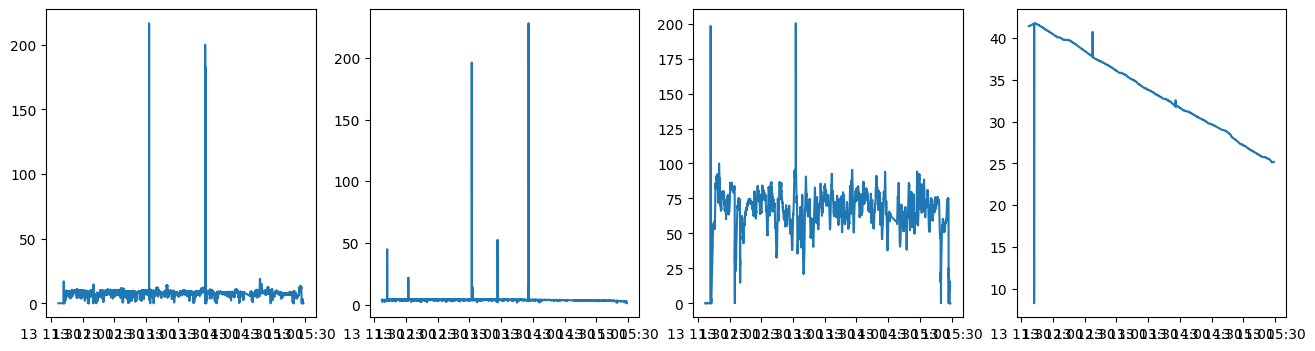

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].plot(d_191013.index, d_191013['Current1'])
axes[1].plot(d_191013.index, d_191013['Current2'])
axes[2].plot(d_191013.index, d_191013['Speed'])
axes[3].plot(d_191013.index, d_191013['SOC'])

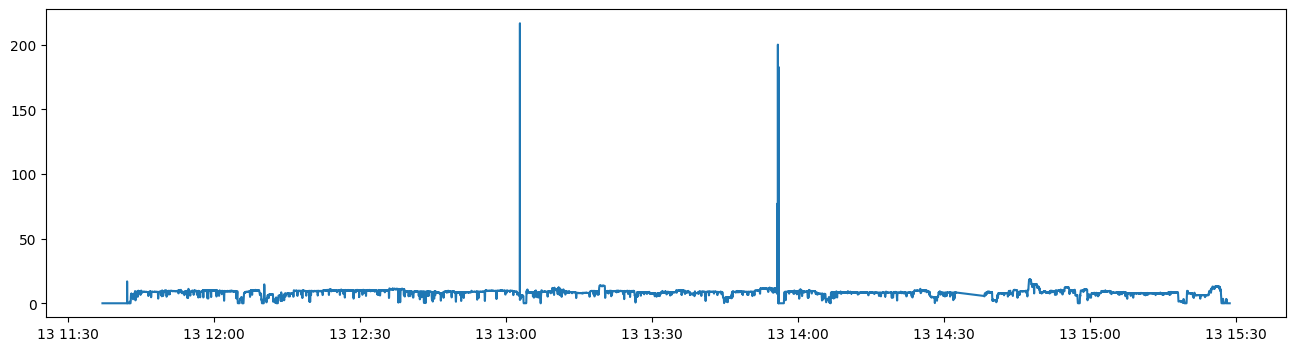

In [11]:
plt.figure(figsize=(16, 4))
plt.plot(d_191013.index, d_191013["Current1"])

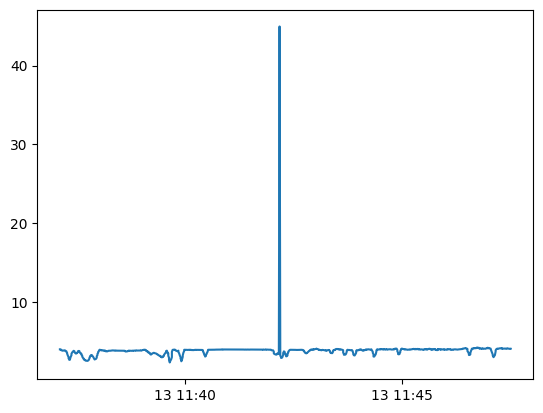

In [12]:
plt.plot(d_191013.iloc[:1000].index, d_191013.iloc[:1000]['Current2'])

In [13]:
d_191013

,Current1,Current2,Voltage,Speed,SOC,Distance
Time,,,,,,
2019-10-13 11:37:07,0.0,4.00,120.16,0.011,41.44,0.000
2019-10-13 11:37:08,0.0,4.00,120.16,0.011,41.44,0.000
2019-10-13 11:37:08,0.0,3.95,120.15,0.022,41.44,0.000
2019-10-13 11:37:09,0.0,3.91,120.15,0.011,41.44,0.000
2019-10-13 11:37:09,0.0,3.88,120.14,0.011,41.44,0.000
...,...,...,...,...,...,...
2019-10-13 15:28:46,0.0,1.14,108.76,0.022,25.18,250.866
2019-10-13 15:28:46,0.0,1.14,108.76,0.033,25.18,250.866
2019-10-13 15:28:47,0.0,1.14,108.76,0.022,25.18,250.866


In [14]:
d_191013.index.minute

Index([37, 37, 37, 37, 37, 37, 37, 37, 37, 37,
       ...
       28, 28, 28, 28, 28, 28, 28, 28, 28, 28],
      dtype='int32', name='Time', length=21651)

In [15]:
df_minute = d_191013.resample('1min').median()

In [16]:
df_minute

,Current1,Current2,Voltage,Speed,SOC,Distance
Time,,,,,,
2019-10-13 11:37:00,0.00,3.335,120.13,0.011,41.460,0.0000
2019-10-13 11:38:00,0.00,3.830,120.25,0.011,41.510,0.0000
2019-10-13 11:39:00,0.00,3.510,120.27,0.022,41.560,0.0000
2019-10-13 11:40:00,0.00,3.940,120.38,0.011,41.630,0.0000
2019-10-13 11:41:00,0.00,3.970,120.42,0.011,41.700,0.0000
...,...,...,...,...,...,...
2019-10-13 15:24:00,6.86,2.970,108.27,57.926,25.490,247.5990
2019-10-13 15:25:00,12.56,2.925,107.56,67.815,25.365,248.6165
2019-10-13 15:26:00,12.69,2.880,107.33,74.316,25.200,249.8210


Text(0.5, 1.0, 'Voltage')

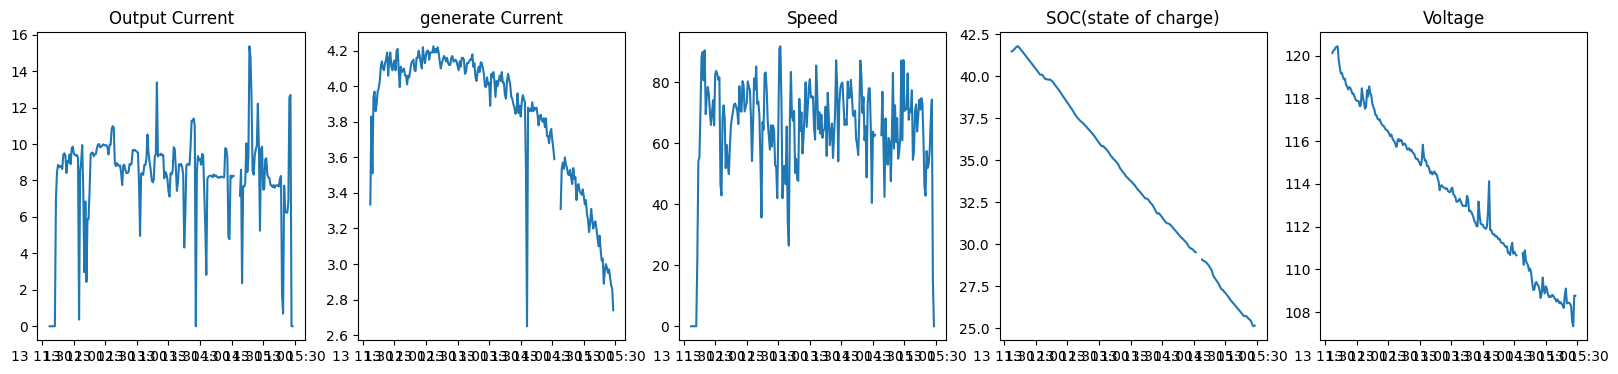

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].plot(df_minute.index, df_minute['Current1'])
axes[0].set_title('Output Current')

axes[1].plot(df_minute.index, df_minute['Current2'])
axes[1].set_title('generate Current')

axes[2].plot(df_minute.index, df_minute['Speed'])
axes[2].set_title('Speed')

axes[3].plot(df_minute.index, df_minute['SOC'])
axes[3].set_title("SOC(state of charge)")

axes[4].plot(df_minute.index, df_minute['Voltage'])
axes[4].set_title("Voltage")

In [19]:
AR_8 = pd.read_csv("19WSC_csv/Australia_Racing_191014_8h.csv")
AR_10 = pd.read_csv("19WSC_csv/Australia_Racing_191014_10h.csv")
AR_13 = pd.read_csv("19WSC_csv/Australia_Racing_191014_13h.csv")

df = pd.concat([AR_8, AR_10, AR_13], axis=0)

full_time_strings = '2019-10-' + df['Time']
df['Time'] = pd.to_datetime(full_time_strings, format='%Y-%m-%d/%H:%M:%S')
df.index = df['Time']

df.drop(["Time", "2"], axis=1, inplace=True)

In [ ]:
df

,Current1,Current2,Voltage,Speed,SOC,Distance
Time,,,,,,
2019-10-14 08:51:08,0.49,2.60,117.87,0.000,35.04,0.000
2019-10-14 08:51:08,0.49,2.61,117.88,0.011,35.04,0.000
2019-10-14 08:51:08,0.49,2.62,117.86,0.000,35.04,0.000
2019-10-14 08:51:09,0.49,2.62,117.85,0.011,35.04,0.000
2019-10-14 08:51:09,0.49,2.63,117.85,0.011,35.04,0.000
...,...,...,...,...,...,...
2019-10-14 15:37:54,0.06,3.28,107.45,0.022,16.05,148.984
2019-10-14 15:37:54,0.06,3.28,107.45,0.011,16.05,148.984
2019-10-14 15:37:55,0.06,3.28,107.46,0.011,16.05,148.984


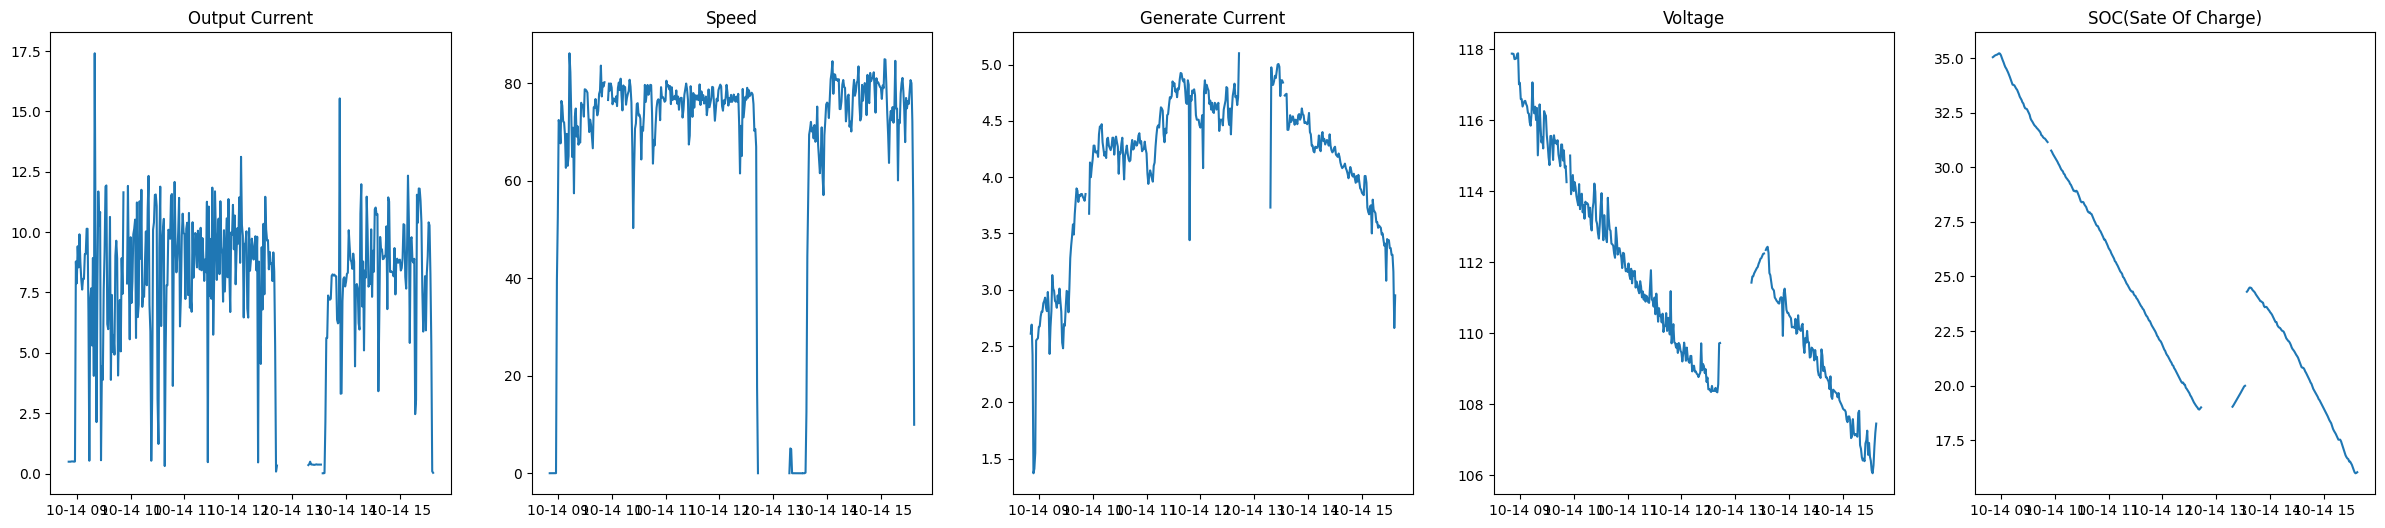

In [20]:
from show_racingdata import show_racing_data

df_minute = df.resample('1min').median()

show_racing_data(df_minute)